# 📉 Bollinger Band Mean Reversion Strategy

## 🔹 Overview
This project implements and backtests a **Bollinger Band Mean Reversion Strategy**.  
The strategy is based on the idea that prices tend to revert back to their mean when they become excessively overbought or oversold relative to their recent history.  

Bollinger Bands are calculated as a moving average plus/minus a multiple of standard deviation, creating a volatility-based envelope around price.

---

## 🔹 Technical Background

### Bollinger Bands
- **Middle Band (MB):**
\[
MB = SMA_{20}(Close)
\]

- **Upper Band (UB):**
\[
UB = MB + 2\sigma_{20}
\]

- **Lower Band (LB):**
\[
LB = MB - 2\sigma_{20}
\]

Where \(\sigma_{20}\) is the standard deviation of the last 20 closes.

---

## 🔹 Strategy Rules
- **Buy Signal:** Price closes **below the Lower Band** (oversold condition).  
- **Exit Signal:** Price closes **above the Middle Band** (return to mean).  
- Strategy is **long-only** (no short selling).  

---

## 🔹 Backtest Framework
The backtest computes:  
- **Equity Curve** (strategy vs Buy & Hold).  
- **Performance Metrics**:  
  - **CAGR (Compound Annual Growth Rate)**  
  - **Sharpe Ratio**  
  - **Max Drawdown (MDD)**  

### Formulas
- CAGR:  
\[
CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{\tfrac{1}{T_{years}}} - 1
\]

- Sharpe Ratio:  
\[
Sharpe = \frac{E[R - R_f]}{\sigma_R} \times \sqrt{252}
\]

- Max Drawdown:  
\[
MDD = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}
\]

---

## 🔹 Implementation Flow
```python
# 1. Load Data
df = load_synthetic()

# 2. Compute Bollinger Bands
df = add_bollinger(df)

# 3. Apply Mean Reversion Strategy
df = bb_mean_reversion(df)

# 4. Run Backtest
backtest(df, "Bollinger Band Mean Reversion")


In [1]:
print("Hello, World!")

Hello, World!


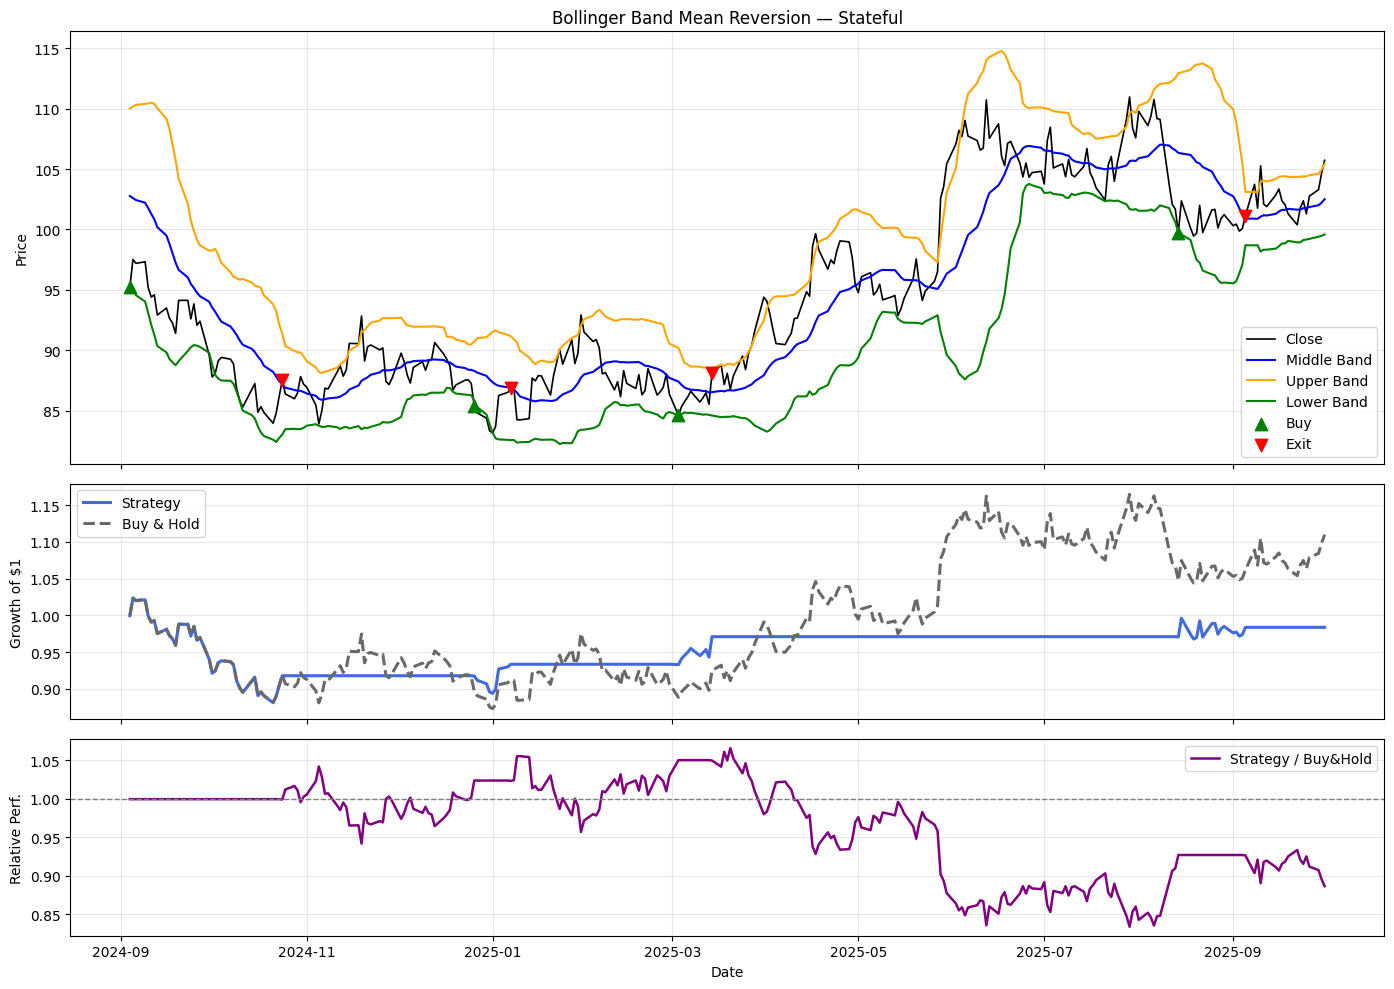

=== Results (stateful strategy) ===
CAGR Strategy  : -1.48%
CAGR Buy&Hold  : 10.18%
Sharpe (Strat) : -0.08
Max DD (Strat) : -13.89%
Trades (entries/exits): 4 / 4
Final Ratio (Strategy/Buy&Hold): 0.886


In [7]:
# ==== Bollinger Band Mean Reversion — Correct stateful strategy ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- Config -----------------
N_BARS     = 300
BB_LEN     = 20
BB_K       = 2.0
COST_PCT   = 0.0005   # 5 bps per entry/exit (set 0 for none)
SEED       = 42
# ------------------------------------------

# --------------- Synthetic Data ---------------
def load_synthetic(n=N_BARS, seed=SEED):
    np.random.seed(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    high = close * (1 + np.random.uniform(0.001, 0.02, size=n))
    low  = close * (1 - np.random.uniform(0.001, 0.02, size=n))
    vol  = pd.Series(np.random.randint(1e6, 5e6, size=n), index=dates, name="Volume")
    return pd.DataFrame({"High": high, "Low": low, "Close": close, "Volume": vol})

# --------------- Bollinger Bands ---------------
def add_bollinger(df, window=BB_LEN, k=BB_K):
    df = df.copy()
    ma  = df["Close"].rolling(window).mean()
    std = df["Close"].rolling(window).std(ddof=0)
    df["BB_MID"] = ma
    df["BB_UP"]  = ma + k*std
    df["BB_LOW"] = ma - k*std
    return df

# --------------- Stateful Strategy ---------------
def bb_mean_reversion_stateful(df, cost_pct=COST_PCT):
    """
    Enter long when Close < Lower Band.
    Exit to cash when Close > Middle Band.
    Uses a proper state machine to avoid 'sticky' positions.
    Applies transaction costs on entry AND exit.
    """
    df = df.copy()
    df = df.dropna(subset=["BB_MID","BB_UP","BB_LOW"])  # ensure bands exist

    enter = df["Close"] < df["BB_LOW"]
    exit_  = df["Close"] > df["BB_MID"]

    position = 0
    positions = []
    trades = []  # +1 for entry, -1 for exit, 0 otherwise

    for i in range(len(df)):
        if position == 0:
            if enter.iloc[i]:
                position = 1
                trades.append(+1)
            else:
                trades.append(0)
        else:  # position == 1
            if exit_.iloc[i]:
                position = 0
                trades.append(-1)
            else:
                trades.append(0)
        positions.append(position)

    df["Position"] = positions
    df["Trade"]    = trades

    # returns
    df["Ret"] = df["Close"].pct_change().fillna(0.0)

    # apply costs on trade days (both entry and exit)
    # cost reduces strategy return on that day by cost_pct
    trade_cost = np.where(df["Trade"] != 0, cost_pct, 0.0)

    df["Strat_Ret_Gross"] = df["Position"].shift(1).fillna(0.0) * df["Ret"]
    df["Strat_Ret"]       = df["Strat_Ret_Gross"] - trade_cost

    # equity curves
    df["Equity_BuyHold"]  = (1.0 + df["Ret"]).cumprod()
    df["Equity_Strategy"] = (1.0 + df["Strat_Ret"]).cumprod()
    df["Eq_Ratio"]        = df["Equity_Strategy"] / df["Equity_BuyHold"]

    return df

# --------------- Metrics ---------------
def CAGR(series):
    years = (series.index[-1] - series.index[0]).days / 365
    return (series.iloc[-1]/series.iloc[0])**(1/years) - 1 if years > 0 else float("nan")

def sharpe(returns, rf=0.0):
    s = returns.std()
    return ((returns.mean() - rf)/s)*np.sqrt(252) if s and not np.isnan(s) else float("nan")

def max_drawdown(series):
    roll_max = series.cummax()
    dd = (series - roll_max)/roll_max
    return dd.min()

# --------------- Run ---------------
df = load_synthetic()
df = add_bollinger(df)
df = bb_mean_reversion_stateful(df)

# --------------- Plots ---------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={'height_ratios':[2.2,1.2,1.0]})

# Price with bands and trades
ax1 = axes[0]
ax1.plot(df.index, df["Close"],  color="black", lw=1.2, label="Close")
ax1.plot(df.index, df["BB_MID"], color="blue",   label="Middle Band")
ax1.plot(df.index, df["BB_UP"],  color="orange", label="Upper Band")
ax1.plot(df.index, df["BB_LOW"], color="green",  label="Lower Band")
buys  = df.index[df["Trade"] == +1]
exits = df.index[df["Trade"] == -1]
ax1.scatter(buys,  df.loc[buys,"Close"],  marker="^", color="green", s=80, label="Buy",  zorder=5)
ax1.scatter(exits, df.loc[exits,"Close"], marker="v", color="red",   s=80, label="Exit", zorder=5)
ax1.set_title("Bollinger Band Mean Reversion — Stateful")
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Equity curves
ax2 = axes[1]
ax2.plot(df.index, df["Equity_Strategy"], color="royalblue", lw=2.2, label="Strategy")
ax2.plot(df.index, df["Equity_BuyHold"],  color="dimgray",   lw=2.2, ls="--", label="Buy & Hold")
ax2.set_ylabel("Growth of $1")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Relative performance
ax3 = axes[2]
ax3.plot(df.index, df["Eq_Ratio"], color="purple", lw=1.8, label="Strategy / Buy&Hold")
ax3.axhline(1.0, color="gray", lw=1, ls="--")
ax3.set_ylabel("Relative Perf.")
ax3.set_xlabel("Date")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# --------------- Report ---------------
print("=== Results (stateful strategy) ===")
print(f"CAGR Strategy  : {CAGR(df['Equity_Strategy']):.2%}")
print(f"CAGR Buy&Hold  : {CAGR(df['Equity_BuyHold']):.2%}")
print(f"Sharpe (Strat) : {sharpe(df['Strat_Ret']):.2f}")
print(f"Max DD (Strat) : {max_drawdown(df['Equity_Strategy']):.2%}")
print(f"Trades (entries/exits): {int((df['Trade']==1).sum())} / {int((df['Trade']==-1).sum())}")
print(f"Final Ratio (Strategy/Buy&Hold): {df['Eq_Ratio'].iloc[-1]:.3f}")
